# Task #4b: Conversation-Level Structural Features

Feature extraction for the *shape* of a conversation rather than the content of
its text, on the standardized Conversations Gone Awry — ChangeMyView corpus.

One row per conversation. Task #4a (`text_features.py`) produces one row per
comment; the two tables join on `conversation_id`.

Feature groups:
- Thread shape: size, depth, breadth, growth rate
- Timing: reply gaps, time to first reply, acceleration
- Participants: speaker counts and concentration
- Trouble signals: deletions, vote levels, vote trajectory

Does not train a model (Task #6) and does not use text (Task #4a).

To run this yourself, download the standardized dataset from Google Drive into
`/data/local/` as described in `data/STANDARDIZATION.md`.

# Summary

### Headline

Structure alone does not separate derailed conversations from civil ones well
enough to drive a model. The strongest single feature reaches 67% accuracy on the
matched-pair framing, where a topic-matched pair is supplied and exactly one of
the two is known to have derailed. Real prediction has no twin to compare
against, so this is an optimistic bound rather than a usable score. These
features are a complement to the Task #4a text features, not a substitute.

### Structure

Every CGA-CMV conversation is a single linear chain, verified directly against
parent references in the standardized file. The corpus stores root-to-leaf
*paths*, not full subtrees. Half the thread-shape ideas in the task description
therefore cannot be evaluated here, and `n_utterances`, `max_depth` and
`mean_depth` are redundant with one another. The branching and placeholder-repair
code paths were validated against Coarse Discourse instead, which has real trees.

Seven columns are constant on this corpus and three more leak the outcome label,
leaving 23 of 35 usable for modeling.

### What mattered

Derailed conversations are **longer, slower and more poorly received**, with
slightly more participants. Thread length is strongest under the matched-pair
comparison; the number of downvoted comments is strongest under the pooled
comparison.

Comparing each conversation against its own topic-matched twin rather than the
pooled average nearly doubles the measured effect for thread length, from 0.197
to 0.350. The pairing cancels topic, community and era variance, which is why the
corpus was built in pairs. Any further analysis here should use it.

### What did not matter

`self_reply_count` ties in 98.9% of pairs — almost nobody replies to themselves.
`gap_acceleration`, `time_to_first_reply`, `min_score_position` and `last_score`
all sit near chance. `deleted_ratio` is slightly *negative*, so derailed threads
have marginally fewer deleted comments by proportion; convenient, since that
family leaks the label and should be dropped regardless.

Two plausible hypotheses were wrong, both opposite to the obvious guess.
Rapid-fire replies do not signal escalation: derailed threads are slower, with a
median reply gap roughly three times longer, and they accumulate comments more
slowly. Two-person duels do not derail more often either; derailed threads have
slightly more speakers and slightly lower two-person concentration. Neither is
worth re-testing on this corpus.

### Modeling implications for Task #6

- Join on `conversation_id` after aggregating the text table to conversation grain.
- Call `model_ready_columns(df)` rather than maintaining a column list by hand;
  which columns are unusable is corpus-dependent.
- Use one of the three size features, not all three.
- Prefer rank-based or log-transformed timing features over raw seconds. Effect
  size and pair accuracy disagree for timing because those features are heavily
  right-skewed.
- Honour the corpus splits — train 4,106, val 1,368, test 1,368 — and keep pairs
  together. Both members of a pair always share a split.
- Expect a modest contribution, and compute features under a `first_n` cutoff so
  the outcome sits outside the window.
- The generated tables live in Git-ignored `data/local/` and belong on the shared
  Drive. **They cannot be obtained from Git.**

## 0. Setup

In [1]:
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

current = Path.cwd()
REPO_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT / "artifacts"))

from standardize_convokit import iter_standardized
from structural_features import (
    LEAKY_FEATURES,
    degenerate_columns,
    extract_conversation_features,
    model_ready_columns,
)

data_candidates = [
    REPO_ROOT / "data" / "local" / "standardized-v1-regenerated",
    REPO_ROOT / "data" / "local" / "standardized-v1",
]
DATA_DIR = next(path for path in data_candidates if path.exists())

CMV_PATH = DATA_DIR / "conversations-gone-awry-cmv-corpus.jsonl"
COARSE_PATH = DATA_DIR / "reddit-coarse-discourse-corpus.jsonl"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

# Two-series categorical palette, checked for colour-vision separation.
CIVIL, DERAILED = "#2a78d6", "#eb6834"
INK, INK_MUTED = "#0b0b0b", "#52514e"

print(f"Repository: {REPO_ROOT}")
print(f"Dataset:    {DATA_DIR}")

Repository: /Users/tiffanycalle/Documents/BTT/Fall AI Studio Project/Market-Research-1B-discussion-intelligence-toolkit
Dataset:    /Users/tiffanycalle/Documents/BTT/Fall AI Studio Project/Market-Research-1B-discussion-intelligence-toolkit/data/local/standardized-v1


## 1. Build the feature table

`first_n` restricts the features to the earliest N comments. Derailment is a
prediction task, so a model that sees the whole thread can read the outcome
instead of predicting it; see the leakage guidance in `data/STANDARDIZATION.md`.

In [2]:
features = extract_conversation_features(iter_standardized(CMV_PATH))
features_first4 = extract_conversation_features(iter_standardized(CMV_PATH), first_n=4)

print("full threads:", features.shape)
print("first 4 only:", features_first4.shape)

features.head()

full threads: (6842, 35)
first 4 only: (6842, 35)


,conversation_id,source_id,n_utterances,max_depth,mean_depth,max_branching,n_leaves,max_width,depth_ratio,duration_seconds,median_reply_gap,mean_reply_gap,min_reply_gap,max_reply_gap,time_to_first_reply,gap_acceleration,growth_rate_per_hour,n_speakers,top_speaker_share,top_two_speaker_share,self_reply_count,utterances_per_speaker,n_deleted,deleted_ratio,last_utterance_is_deleted,min_score,mean_score,n_negative_score,n_missing_score,root_score,last_score,score_trend,min_score_position,n_synthetic_removed,had_structural_repair
0,reddit:conversations-gone-awry-cmv-corpus:conv...,cue8uxd,10,9,4.5,1,1,1,1.0,46629.0,432.0,5.181000e+03,83.0,28285.0,83.0,8.141079,0.772052,4,0.400000,0.700000,0,2.500000,3,0.3,False,-1,2.800000,1,0,3,2,-1.200000,0.555556,0,False
1,reddit:conversations-gone-awry-cmv-corpus:conv...,cue8y0b,10,9,4.5,1,1,1,1.0,13296029.0,1025.0,1.477337e+06,171.0,13280490.0,4798.0,2.637319,0.002708,6,0.300000,0.600000,0,1.666667,0,0.0,False,1,3.900000,0,0,17,1,-5.800000,0.555556,0,False
2,reddit:conversations-gone-awry-cmv-corpus:conv...,cumazei,3,2,1.0,1,1,1,1.0,483.0,241.5,2.415000e+02,177.0,306.0,306.0,0.578431,22.360248,2,0.666667,1.000000,0,1.500000,0,0.0,False,-9,0.666667,1,0,4,-9,-5.000000,1.000000,0,False
3,reddit:conversations-gone-awry-cmv-corpus:conv...,cumbp9z,3,2,1.0,1,1,1,1.0,24194.0,12097.0,1.209700e+04,10147.0,14047.0,10147.0,1.384350,0.446392,3,0.333333,0.666667,0,1.000000,0,0.0,False,0,15.666667,0,0,38,9,-33.500000,0.500000,0,False
4,reddit:conversations-gone-awry-cmv-corpus:conv...,cunu481,5,4,2.0,1,1,1,1.0,51236.0,7663.5,1.280900e+04,362.0,35547.0,362.0,4.492710,0.351315,4,0.400000,0.600000,0,1.250000,1,0.2,False,-4,-0.200000,2,0,1,2,-0.333333,0.750000,0,False


## 2. Outcome labels, pairs, and splits

CGA-CMV pairs every derailed conversation with a topic-matched conversation that
stayed civil. `pair_id` holds the partner's source identifier.

In [3]:
rows = []
for conversation in iter_standardized(CMV_PATH):
    source_metadata = conversation.metadata["source_metadata"]
    rows.append({
        "conversation_id": conversation.id,
        "derailed": source_metadata.get("has_removed_comment"),
        "pair_id": source_metadata.get("pair_id"),
        "split": source_metadata.get("split"),
    })

labels = pd.DataFrame(rows).set_index("conversation_id")

analysis = features.set_index("conversation_id").join(labels)
source_to_id = features.set_index("source_id")["conversation_id"].to_dict()
analysis["partner"] = analysis["pair_id"].map(source_to_id)

print("label balance:", analysis["derailed"].mean())
print(analysis["split"].value_counts().to_string())
print("\npairs resolved:", analysis["partner"].notna().sum(), "of", len(analysis))

label balance: 0.5
split
train    4106
val      1368
test     1368

pairs resolved: 6842 of 6842


## 3. Thread shape

Every CGA-CMV conversation turns out to be a single linear chain. The check
below reads parent references straight from the standardized file, so it does
not depend on the feature module's own tree handling.

In [4]:
max_children = []
for conversation in iter_standardized(CMV_PATH):
    counts = {}
    for utterance in conversation.utterances:
        if utterance.parent_id is not None:
            counts[utterance.parent_id] = counts.get(utterance.parent_id, 0) + 1
    max_children.append(max(counts.values()) if counts else 0)

print("max direct replies to any single comment, across conversations:")
print(pd.Series(max_children).value_counts().to_string())

print("\nshape columns in the feature table:")
for column in ["max_branching", "n_leaves", "max_width", "depth_ratio"]:
    print(f"  {column:<16} unique values: {features[column].nunique()}")

print("\nsize features are redundant here:")
print((features["max_depth"] == features["n_utterances"] - 1).all())

max direct replies to any single comment, across conversations:
1    6842

shape columns in the feature table:
  max_branching    unique values: 1
  n_leaves         unique values: 1
  max_width        unique values: 1
  depth_ratio      unique values: 1

size features are redundant here:
True


## 4. Unusable columns

Which columns carry no information depends on the corpus, so the module reports
them rather than hard-coding a list. `model_ready_columns` also drops the leaky
deletion family, because `has_removed_comment` is itself defined as a moderator
removing a comment.

In [5]:
print("constant on CGA-CMV:")
for column in degenerate_columns(features):
    print(f"  {column}")

print("\nleaky (restate the outcome label):")
for column in LEAKY_FEATURES:
    print(f"  {column}")

usable = model_ready_columns(features)
print(f"\nusable for modeling: {len(usable)} of {features.shape[1]} columns")

constant on CGA-CMV:
  max_branching
  n_leaves
  max_width
  depth_ratio
  n_missing_score
  n_synthetic_removed
  had_structural_repair

leaky (restate the outcome label):
  n_deleted
  deleted_ratio
  last_utterance_is_deleted

usable for modeling: 23 of 35 columns


## 5. How fast conversations grow

`growth_rate_per_hour` is one of the stronger new features, so it is worth seeing
the trajectory behind it rather than only the summary statistic. The chart tracks
how long each conversation took to reach its *n*-th comment, using medians because
the elapsed times are heavily right-skewed.

In [6]:
elapsed_rows = []
for conversation in iter_standardized(CMV_PATH):
    ordered = sorted(
        (u for u in conversation.utterances if not u.metadata.get("is_synthetic")),
        key=lambda u: u.created_at,
    )
    start = ordered[0].created_at
    for position, utterance in enumerate(ordered, start=1):
        elapsed_rows.append({
            "conversation_id": conversation.id,
            "position": position,
            "hours": (utterance.created_at - start).total_seconds() / 3600,
        })

growth = (
    pd.DataFrame(elapsed_rows)
    .merge(labels[["derailed"]], left_on="conversation_id", right_index=True)
)

trajectory = (
    growth[growth["position"] <= 10]
    .groupby(["derailed", "position"])["hours"]
    .median()
    .unstack(0)
)
trajectory.columns = ["civil", "derailed"]
trajectory

,civil,derailed
position,,
1,0.000000,0.000000
2,0.309444,0.490278
3,0.810556,1.422222
4,1.355556,2.585972
5,2.107778,3.625833
6,2.831111,4.930278
7,3.446944,5.740417
8,4.006111,7.077917
9,4.946667,7.984444


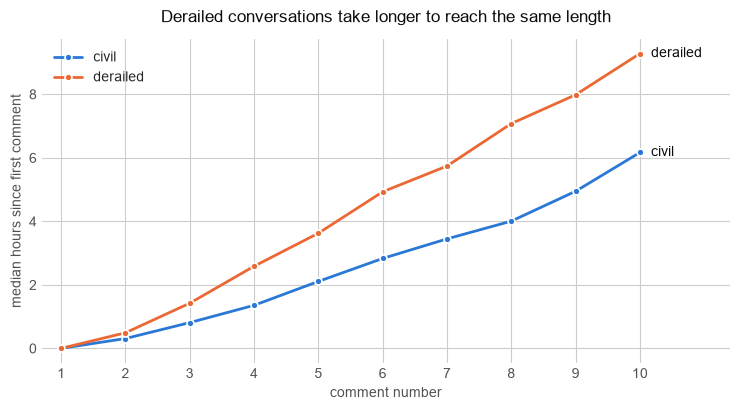

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

for name, colour in [("civil", CIVIL), ("derailed", DERAILED)]:
    ax.plot(
        trajectory.index, trajectory[name],
        color=colour, linewidth=2, marker="o", markersize=5,
        markeredgecolor="white", markeredgewidth=1.2, label=name,
    )
    # Direct label at the end of each line, in ink rather than the series colour.
    last = trajectory[name].dropna()
    ax.annotate(
        name, (last.index[-1], last.iloc[-1]),
        xytext=(8, 0), textcoords="offset points",
        color=INK, fontsize=10, va="center",
    )

ax.set_title("Derailed conversations take longer to reach the same length", color=INK, fontsize=12, pad=12)
ax.set_xlabel("comment number", color=INK_MUTED)
ax.set_ylabel("median hours since first comment", color=INK_MUTED)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.7, 11.4)
ax.legend(frameon=False, loc="upper left")
ax.tick_params(colors=INK_MUTED)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

The gap widens with every comment: a derailed thread is consistently slower to
reach the same number of comments. This is the shape behind `growth_rate_per_hour`
being negative for derailed threads, and it contradicts the intuition that
hostility arrives as a rapid-fire exchange.

## 6. Reply-gap distributions

The growth curve uses medians, so it could hide a subpopulation of fast, angry
threads. Plotting the full distribution of reply gaps rules that out. The x axis
is logarithmic because the gaps span seconds to weeks.

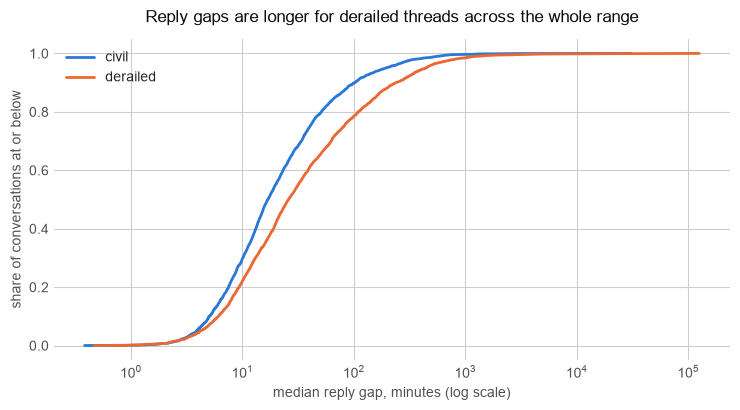

In [8]:
gaps = analysis[["median_reply_gap", "derailed"]].dropna()
gaps = gaps[gaps["median_reply_gap"] > 0]

fig, ax = plt.subplots(figsize=(7.5, 4.2))

for name, flag, colour in [("civil", False, CIVIL), ("derailed", True, DERAILED)]:
    values = gaps.loc[gaps["derailed"] == flag, "median_reply_gap"].sort_values() / 60
    share = (values.rank(method="first") - 1) / (len(values) - 1)
    ax.plot(values.values, share.values, color=colour, linewidth=2, label=name)

ax.set_xscale("log")
ax.set_title("Reply gaps are longer for derailed threads across the whole range", color=INK, fontsize=12, pad=12)
ax.set_xlabel("median reply gap, minutes (log scale)", color=INK_MUTED)
ax.set_ylabel("share of conversations at or below", color=INK_MUTED)
ax.legend(frameon=False, loc="upper left")
ax.tick_params(colors=INK_MUTED)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

The derailed curve sits to the right of the civil curve at every percentile, so
the effect is a shift of the whole distribution rather than a fast-thread tail.
There is no subpopulation of rapid hostile exchanges.

## 7. Pooled versus matched-pair comparison

Two ways to ask whether a feature separates the classes.

**Pooled** compares all derailed conversations against all civil ones. It mixes
in every difference between topics, communities and eras.

**Paired** compares each derailed conversation against its own topic-matched
twin, which is the comparison the corpus was designed for.

`pair_accuracy` is the share of pairs where the feature alone picks the derailed
thread correctly, counting ties as half credit. Chance is 50%.

In [9]:
numeric = [
    column for column in model_ready_columns(analysis.reset_index())
    if column in analysis.columns and analysis[column].dtype.kind in "if"
]

derailed_rows = analysis[analysis["derailed"] == True]
civil_rows = analysis[analysis["derailed"] == False]

comparison = []
for column in numeric:
    spread = analysis[column].std()
    if not spread:
        continue
    pooled = (derailed_rows[column].mean() - civil_rows[column].mean()) / spread

    twin_values = analysis.loc[derailed_rows["partner"].values, column].values
    difference = pd.Series(derailed_rows[column].values - twin_values).dropna()
    if len(difference) < 100 or not difference.std():
        continue

    ties = (difference == 0).mean()
    accuracy = max(
        (difference > 0).mean() + 0.5 * ties,
        (difference < 0).mean() + 0.5 * ties,
    )
    comparison.append({
        "feature": column,
        "pooled": pooled,
        "paired": difference.mean() / difference.std(),
        "tie_rate": ties,
        "pair_accuracy": accuracy,
    })

comparison = (
    pd.DataFrame(comparison)
    .assign(magnitude=lambda frame: frame["paired"].abs())
    .sort_values("magnitude", ascending=False)
    .drop(columns="magnitude")
    .reset_index(drop=True)
)
comparison

,feature,pooled,paired,tie_rate,pair_accuracy
0,n_utterances,0.197431,0.349688,0.627010,0.607279
1,mean_depth,0.197431,0.349688,0.627010,0.607279
2,max_depth,0.197431,0.349688,0.627010,0.607279
3,n_negative_score,0.236801,0.187990,0.439930,0.571032
4,growth_rate_per_hour,-0.189493,-0.154288,0.000000,0.648348
5,n_speakers,0.182273,0.153700,0.392283,0.548670
6,min_score,-0.166494,-0.120365,0.155510,0.598948
7,root_score,0.159453,0.118610,0.053493,0.540339
8,top_two_speaker_share,-0.127680,-0.100391,0.338205,0.527770
9,score_trend,-0.122262,-0.091055,0.021923,0.544139


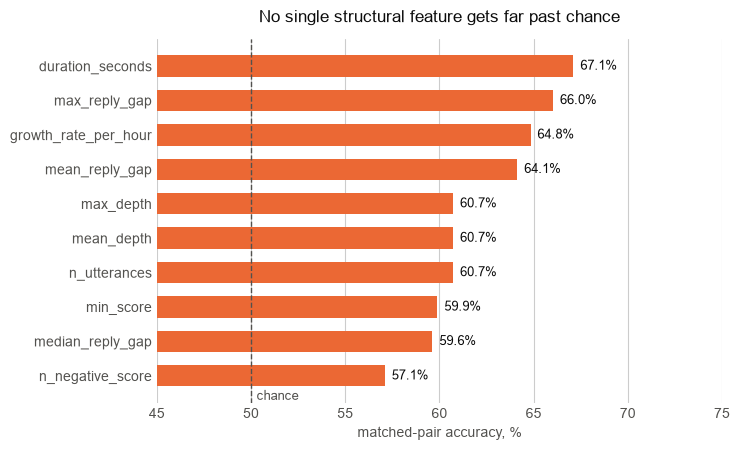

In [10]:
top = comparison.nlargest(10, "pair_accuracy").sort_values("pair_accuracy")

fig, ax = plt.subplots(figsize=(7.5, 4.6))

ax.barh(
    top["feature"], top["pair_accuracy"] * 100,
    color=DERAILED, height=0.62,
)
ax.axvline(50, color=INK_MUTED, linewidth=1, linestyle="--")
ax.annotate(
    "chance", (50, -0.7), xytext=(4, 0), textcoords="offset points",
    color=INK_MUTED, fontsize=9,
)

for name, value in zip(top["feature"], top["pair_accuracy"] * 100):
    ax.annotate(
        f"{value:.1f}%", (value, name), xytext=(5, 0), textcoords="offset points",
        va="center", color=INK, fontsize=9,
    )

ax.set_title("No single structural feature gets far past chance", color=INK, fontsize=12, pad=12)
ax.set_xlabel("matched-pair accuracy, %", color=INK_MUTED)
ax.set_xlim(45, 75)
ax.tick_params(colors=INK_MUTED)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

Pairing nearly doubles the effect for thread length, from 0.197 to 0.350, which
is what removing topic variance is expected to do.

The tie rates matter when reading the table. 62.7% of pairs have identical
length, so the length effect is driven by a minority of pairs even though the
direction is consistent.

Effect size and pair accuracy disagree for the timing features: `duration_seconds`
has the best accuracy but a modest effect size, because it is heavily
right-skewed and the standard deviation it divides by is inflated. Rank-based or
log-transformed timing features would suit Task #6 better than raw seconds.

In [11]:
print("direction of the main effects (mean values):")
summary = analysis.groupby("derailed")[
    ["n_utterances", "duration_seconds", "median_reply_gap",
     "growth_rate_per_hour", "n_speakers", "n_negative_score"]
].mean()
summary.T

direction of the main effects (mean values):


derailed,False,True
n_utterances,5.954107,6.604794
duration_seconds,36778.907922,102532.771120
median_reply_gap,3570.728880,11423.307366
growth_rate_per_hour,5.241009,3.466161
n_speakers,2.913183,3.125402
n_negative_score,0.616779,0.857936


## 8. Cutoff sweep

How much signal survives when the model is only allowed to see the opening of
the thread, and how much of the corpus remains usable at each cutoff.

In [12]:
sweep = []
for cutoff in [2, 3, 4, 5, None]:
    table = extract_conversation_features(
        iter_standardized(CMV_PATH), first_n=cutoff
    ).set_index("conversation_id").join(labels)

    columns = [
        column for column in model_ready_columns(table.reset_index())
        if column in table.columns and table[column].dtype.kind in "if"
    ]
    best_feature, best_value = None, 0.0
    for column in columns:
        spread = table[column].std()
        if not spread:
            continue
        value = (
            table[table["derailed"] == True][column].mean()
            - table[table["derailed"] == False][column].mean()
        ) / spread
        if abs(value) > abs(best_value):
            best_feature, best_value = column, value

    sweep.append({
        "first_n": cutoff or "full",
        "strongest_feature": best_feature,
        "pooled_effect": best_value,
        "coverage": (table["n_utterances"] >= (cutoff or 0)).mean(),
    })

pd.DataFrame(sweep)

,first_n,strongest_feature,pooled_effect,coverage
0,2,root_score,0.159453,1.000000
1,3,root_score,0.159453,0.893014
2,4,growth_rate_per_hour,-0.171691,0.771558
3,5,growth_rate_per_hour,-0.177358,0.641479
4,full,n_negative_score,0.236801,1.000000


Signal grows with the cutoff while coverage shrinks; `first_n=4` is a reasonable
compromise. At the tightest cutoffs the strongest predictor is `root_score`,
meaning how the opening post was received before the argument develops.

## 9. Validation on Coarse Discourse

CGA-CMV cannot exercise the branching, width or placeholder-repair code paths,
because its threads are chains and it contains no repaired conversations. Coarse
Discourse has real trees, so it is used here to confirm those paths work.

In [13]:
coarse = extract_conversation_features(
    itertools.islice(iter_standardized(COARSE_PATH), 2000)
)

print(f"{len(coarse)} Coarse Discourse conversations\n")
print("tree features now vary:")
for column in ["max_branching", "n_leaves", "max_width", "depth_ratio"]:
    print(f"  {column:<16} {coarse[column].min()} to {coarse[column].max()}")

print("\nstructural repairs exercised:")
print(f"  conversations repaired: {int(coarse['had_structural_repair'].sum())}")
print(f"  most placeholders removed from one conversation: {int(coarse['n_synthetic_removed'].max())}")

print("\nconstant on this corpus (no timestamps anywhere in Coarse Discourse):")
for column in degenerate_columns(coarse):
    print(f"  {column}")

2000 Coarse Discourse conversations

tree features now vary:
  max_branching    0 to 36
  n_leaves         1 to 37
  max_width        1 to 36
  depth_ratio      0.0 to 1.0

structural repairs exercised:
  conversations repaired: 25
  most placeholders removed from one conversation: 7

constant on this corpus (no timestamps anywhere in Coarse Discourse):
  duration_seconds
  median_reply_gap
  mean_reply_gap
  min_reply_gap
  max_reply_gap
  time_to_first_reply
  gap_acceleration
  growth_rate_per_hour
